# Inhomogeneous waves
In this example, the curved floating bridge created in the model creation examples is exposed to wind and wave excitation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from wawi.model import Model, Windstate, Seastate
from wawi.plot import plot_surface, animate_surface

# Import of WAWI-model
First, the model of the simple curved floating bridge (defined in the model generation examples) is imported. Thereafter, the number of dry modes is defined together with the frequency axes of the FRF (`omega`) of the combined system and the aerodynamics (`omega_aero`).

In [2]:
# Import model
model = Model.from_wwi('./input/model_curved.wwi')
model.n_modes = 50      # define number of dry modes

# Define omega for FRF of system and aerodynamics
omega = np.arange(0.001, 2, 0.005)
omega_aero = np.arange(0.001, 2, 0.05)

## Defining inhomogeneous `Seastate`
Inhomogeneous sea states are defined in the exact same manner as homogeneous sea state. The only difference is that inhomogeneous properties are defined as functions of x and/or y. These correspond to the location in the wave field; the location of all pontoons are automatically used for the wave action on pontoons.

As for homogeneous sea states, it can be defined either directly from initiation of the `Seastate` object or by importing a json file. The resulting `seastate` object is thereafter assigned to the model using the `assign_seastate` method. When using the json-definition procedure, lambda functions are provided as strings that are interpreted on import. When initiating the `Seastate` object directly, any function can be used (e.g., `lambda` or `def`).

In [3]:
# Define Seastate  (JONSWAP 1d wave spectrum and cos2s distribution) either from direct initiation of object
Hs = lambda x: 2.1 - 0.5*x/1500
Tp = lambda x,y: 8.3 + 0.1*x/1500 + 0.1*y/100
gamma = 8
s = 12
theta0 = lambda x: 90.0 - 10.0*x/1500
seastate = Seastate(Tp, Hs, gamma, theta0, s, centered_dirdist=False)

# or from json
seastate = Seastate.from_json('./input/seastate_example_inhomogeneous.json')

# Apply seastate to model
model.assign_seastate(seastate)

In the example above, the seastate is defined as a complex seastate with the following properties:

* $H_s$ varies linearly from 2.1m at x=0 to 1.5m at x=1500m (and 2.6 m at x = -1500m)
* $T_p$ varies colinearly from 8.3s at x,y=0,0; up 0.1s per 1500 m in x-direction and up 0.1s per 100 m in y-direction
* $\gamma$ = 8
* s = 12
* $\theta_0$ varies linearly from 90.0 degrees at x=0 to 80 deg at x=1500m (and 100 deg at x = -1500m)
  

### Plot surface

To visualize a realization of the seastate, it can first be Monte Carlo simulated using the `simulate` method of the `SeaState` object, over a specified grid of `x` and `y` coordinates:

In [4]:
x = np.arange(-1500, 1500, 2)
y = np.arange(-300, 50, 2)
omega = np.arange(0.01, 3.0, 0.05)

eta,t = seastate.simulate(x, y, omega, fs=20.0)

[ ==================== ] 100%  |   x=1498.0m, y=48.0m    

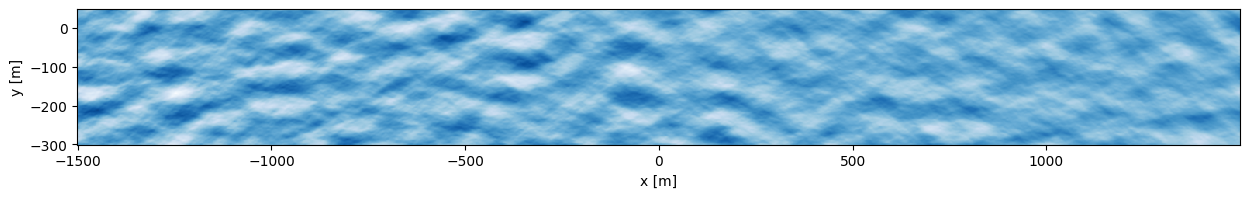

In [5]:
plot_surface(eta[:,:,0], x, y, colorbar=False,figsize=(15,10)); # plot generated surface at time t=0

### Animate surface
By default, the `seastate.simulate` method returns the time history (time axis indirectly defined by input parameters; see code reference for details)  of the sea surface elevation. This can therefore also be animated, as is done below using the `animate_surface` function:

MovieWriter ffmpeg unavailable; using Pillow instead.


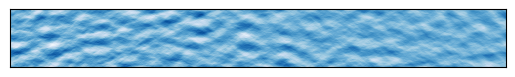

In [6]:
animate_surface(eta, x, y, t, filename='out.gif')

## Response prediction
Note that WAWI is built on assuming general inhomogeneous sea states, the response prediction procedure or computational effort are therefore not affected by the introduction of inhomogeneous sea states. More advanced response prediction functionality is therefore showcased in different examples. In the following code cell, the response is predicted and the standard deviation of the girder forces plotted:

In [10]:
model.aero = None
model.run_freqsim(omega, print_progress=False)
resp_std = model.get_result_std(key='girder_forces')          # standard deviation

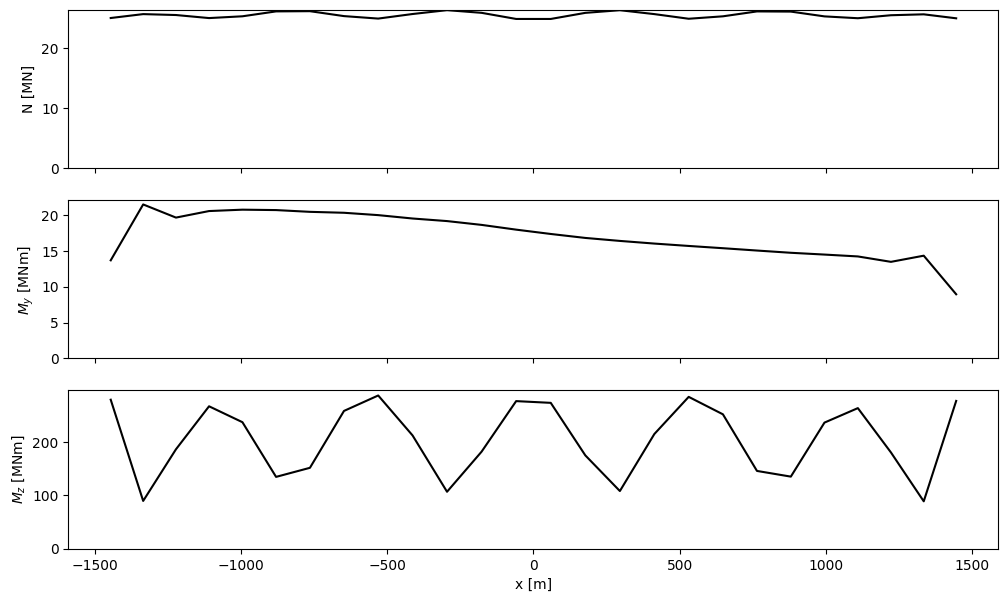

In [15]:
# Plot standard deviations
legend_ax = []
comps = {'N [MN]':0, '$M_y$ [MNm]':4, '$M_z$ [MNm]':5}
arclength_girder_force = model.modal_dry.phi_x['girder_forces'][:, 0]

fig,ax = plt.subplots(nrows=len(comps), sharex=True, figsize=[12,7])
if np.ndim(ax)==0:
    ax = [ax]

for ix, comp in enumerate(comps):
    comp_ix = comps[comp]
    ax[ix].set_ylabel(comp)
    ax[ix].plot(arclength_girder_force, resp_std[comp_ix::6]/1e6, color='black')
    ax[ix].set_ylim(bottom=0)
    
ax[-1].set_xlabel('x [m]');